Frecuencia de muestreo: 44100 Hz
Duración de la señal: 2.995374149659864 segundos
Valor máximo después de normalización: 1.0
Media de la señal escalada: 2.6625988235923087e-18
Desviación estándar de la señal escalada: 1.0
Dimensiones de la matriz de mezcla: (132096, 6)


c:\Users\emili\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_fastica.py:595: UserWarning: n_components is too large: it will be set to 6
  warnings.warn(


Componentes independientes extraídas mediante ICA.


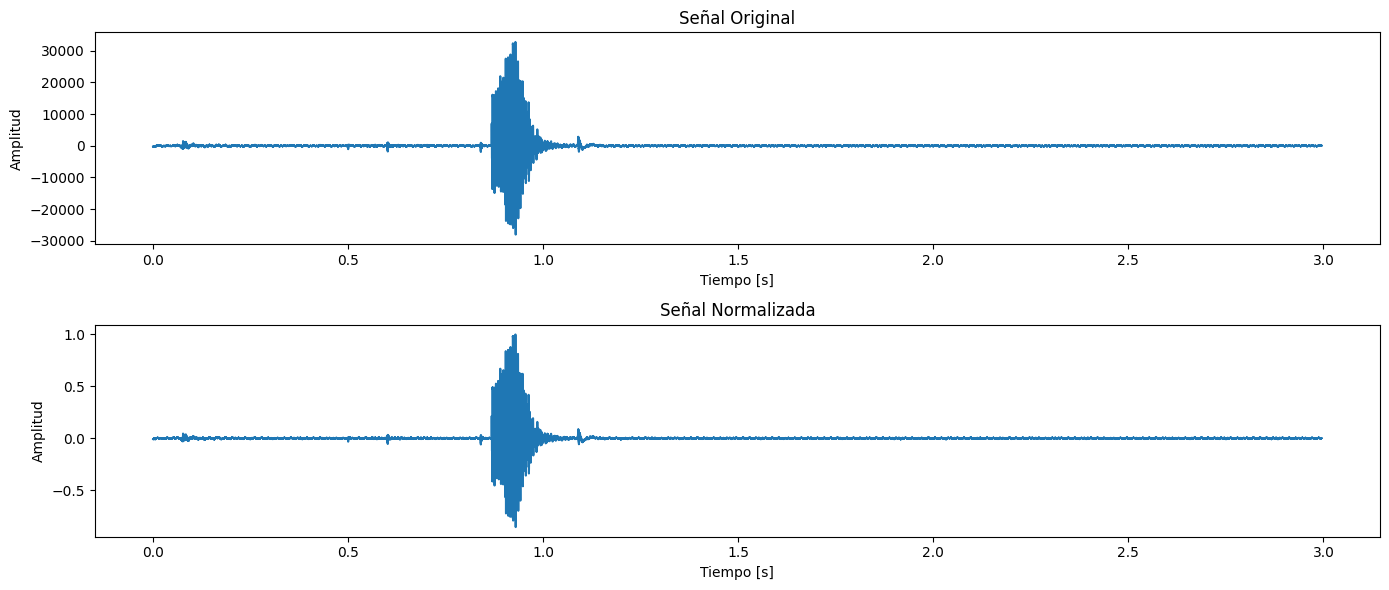

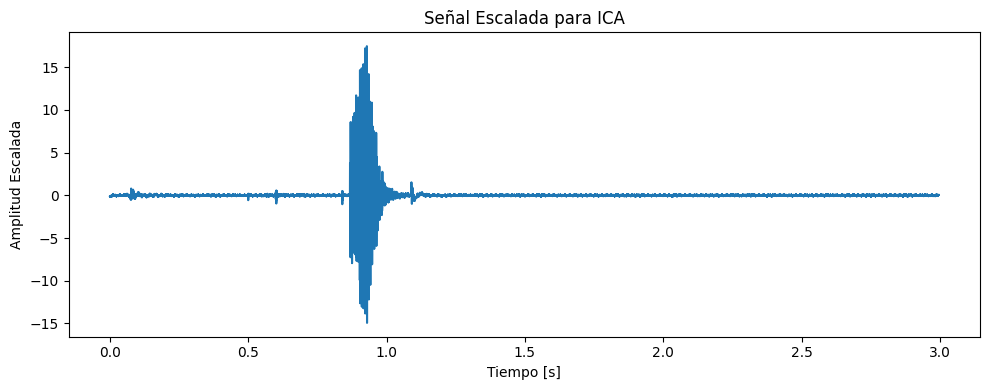

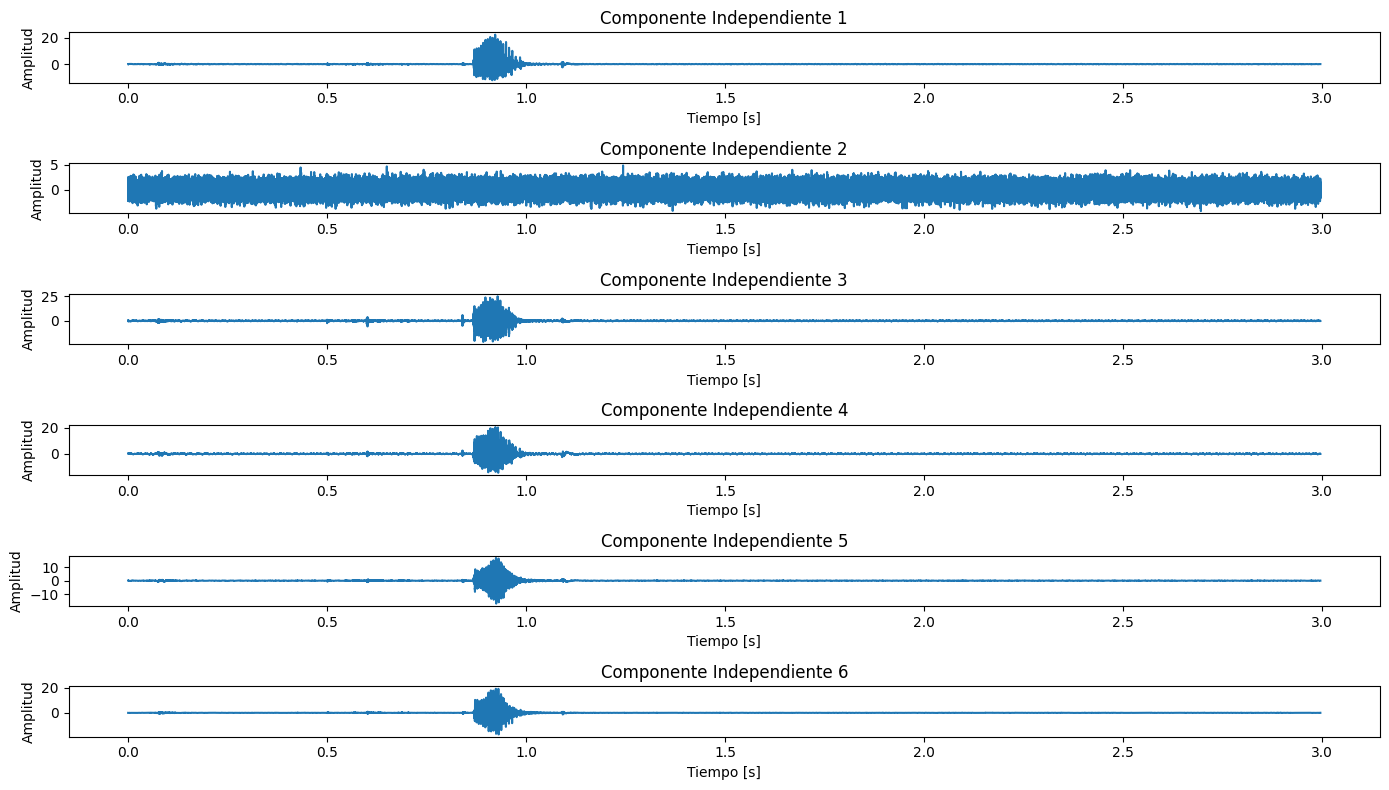

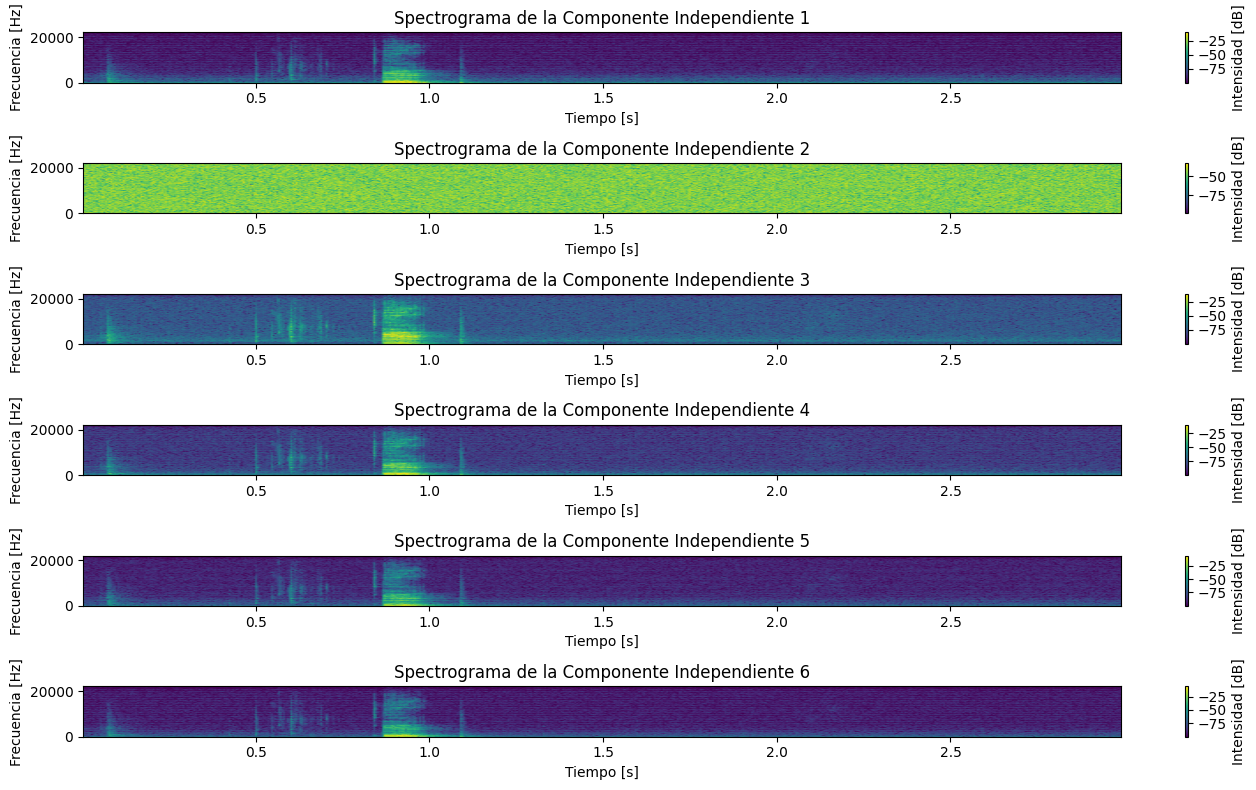

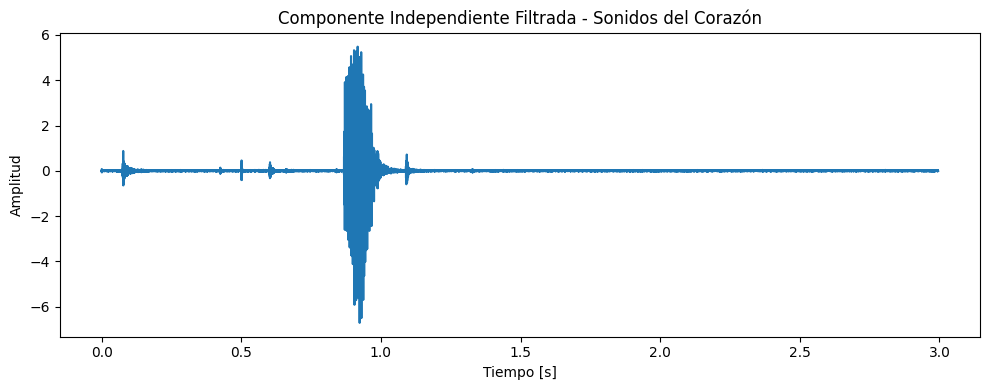

In [7]:
#ICA

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
from scipy.signal import butter, lfilter, spectrogram, find_peaks

#Filtro Pasabajas
def butter_filter(data, cutoff, fs, order=5, btype='low'):
    nyquist = 0.5 * fs
    if isinstance(cutoff, (list, tuple, np.ndarray)):
        # Normalizar las frecuencias de corte para filtros de banda
        normal_cutoff = [c / nyquist for c in cutoff]
    else:
        # Normalizar la frecuencia de corte para filtros de un solo polo
        normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    y = lfilter(b, a, data)
    return y

# Función para introducir un delay en la señal
def introduce_delay(data, delay_samples):
    delayed_signal = np.roll(data, delay_samples)
    # Para los valores retrasados que salen del array, los ponemos en cero
    delayed_signal[:delay_samples] = 0
    return delayed_signal

ruta_señal = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\up1.wav"

# Cargar la señal de sonido
fs, señal = wavfile.read(ruta_señal)  # fs es la frecuencia de muestreo
# señal=señal[46167444:]
 
# Verificar información de la señal
print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Duración de la señal: {len(señal) / fs} segundos")

if len(señal.shape) == 2:
    señal = señal.mean(axis=1)
 
# Normalizar la señal
señal_normalizada = señal / np.max(np.abs(señal))
 
# Verificar la normalización
print(f"Valor máximo después de normalización: {np.max(señal_normalizada)}")
 
# Crear un vector de tiempo
tiempo = np.linspace(0, len(señal) / fs, num=len(señal))
 
# Graficar la señal original y normalizada
plt.close('all')
plt.figure(figsize=(14, 6))
 
plt.subplot(2, 1, 1)
plt.plot(tiempo, señal)
plt.title('Señal Original')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
 
plt.subplot(2, 1, 2)
plt.plot(tiempo, señal_normalizada)
plt.title('Señal Normalizada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
 
plt.tight_layout()

# Escalado estándar de la señal normalizada
scaler = StandardScaler()
señal_escalada = scaler.fit_transform(señal_normalizada.reshape(-1, 1)).flatten()
 
# Verificar el escalado
print(f"Media de la señal escalada: {np.mean(señal_escalada)}")
print(f"Desviación estándar de la señal escalada: {np.std(señal_escalada)}")
 
# Graficar la señal escalada
plt.figure(figsize=(10, 4))
plt.plot(tiempo, señal_escalada)
plt.title('Señal Escalada para ICA')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud Escalada')
plt.tight_layout()

# a) Introducir diferentes retrasos
delay_samples = int(0.001 * fs)  # 1 ms de retraso
señal_delay1 = introduce_delay(señal_escalada, delay_samples)
señal_delay2 = introduce_delay(señal_escalada, 2 * delay_samples)
 
# b) Aplicar diferentes filtros
señal_low = butter_filter(señal_escalada, cutoff=500, fs=fs, btype='low')  # Pasa-bajo 500 Hz
señal_high = butter_filter(señal_escalada, cutoff=1500, fs=fs, btype='high')  # Pasa-alto 1500 Hz
4
# c) Añadir ruido blanco de baja amplitud
np.random.seed(0)  # Para reproducibilidad
ruido = np.random.normal(0, 0.01, len(señal_escalada))
señal_noise = señal_escalada + ruido

# Organizar las versiones en una matriz donde cada columna es una versión diferente
mezcla = np.vstack((señal_escalada, señal_delay1, señal_delay2, señal_low, señal_high, señal_noise)).T
 
print(f"Dimensiones de la matriz de mezcla: {mezcla.shape}")

n_componentes = 10  # Por ejemplo, 2 componentes independientes, simula que la señal está compuesta de n señales
 
# Inicializar FastICA
ica = FastICA(n_components=n_componentes, random_state=0)
 
# Ajustar el modelo ICA
componentes = ica.fit_transform(mezcla)  # Señales independientes, aplicar finspeaks para determinar la frecuencia cardiaca
mezcla_inversa = ica.inverse_transform(componentes)
 
print("Componentes independientes extraídas mediante ICA.")
 
# 4. Visualización de las Componentes Extraídas
 
# Crear un nuevo vector de tiempo para las componentes
tiempo_componentes = tiempo[:len(componentes)]

tiempo_componentes = tiempo[:len(componentes)]
 
plt.figure(figsize=(14, 8))
 
for i in range(componentes.shape[1]):
    plt.subplot(componentes.shape[1], 1, i+1)
    plt.plot(tiempo_componentes, componentes[:, i])
    plt.title(f'Componente Independiente {i+1}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
 
plt.tight_layout()

# Por ejemplo, graficar el espectrograma de cada componente
plt.figure(figsize=(14, 8))
 
for i in range(componentes.shape[1]):
    f, t_spec, Sxx = spectrogram(componentes[:, i], fs)
    plt.subplot(componentes.shape[1], 1, i+1)
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')  # Añadido 1e-10 para evitar log(0)
    plt.title(f'Spectrograma de la Componente Independiente {i+1}')
    plt.ylabel('Frecuencia [Hz]')
    plt.xlabel('Tiempo [s]')
    plt.colorbar(label='Intensidad [dB]')
 
plt.tight_layout()

indice_componente_corazon = 2  # 0 para la primera componente, 1 para la segunda, etc.
 
componente_corazon = componentes[:, indice_componente_corazon]
 
# Definir un rango de frecuencia para el filtro de banda (ejemplo: 300 Hz a 1500 Hz)
frecuencia_inferior = 300
frecuencia_superior = 1500
 
# Aplicar filtro de banda correctamente
componente_corazon_filtrada = butter_filter(
    componente_corazon,
    cutoff=[frecuencia_inferior, frecuencia_superior],
    fs=fs,
    btype='band',
    order=4
)
 
# Graficar la componente filtrada
plt.figure(figsize=(10, 4))
plt.plot(tiempo_componentes, componente_corazon_filtrada)
plt.title('Componente Independiente Filtrada - Sonidos del Corazón')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.tight_layout()

señal_corazon = scaler.inverse_transform(componente_corazon_filtrada.reshape(-1, 1)).flatten()
 
# Normalizar nuevamente para evitar clipping
señal_corazon_normalizada = señal_corazon / np.max(np.abs(señal_corazon))
 
# # Guardar la señal como un archivo WAV
# ruta_guardado = 'sonidos_corazon.wav'
# wavfile.write(ruta_guardado, fs, señal_corazon_normalizada.astype(np.float32))
 
# print(f"Componente filtrada guardada como '{ruta_guardado}'.")



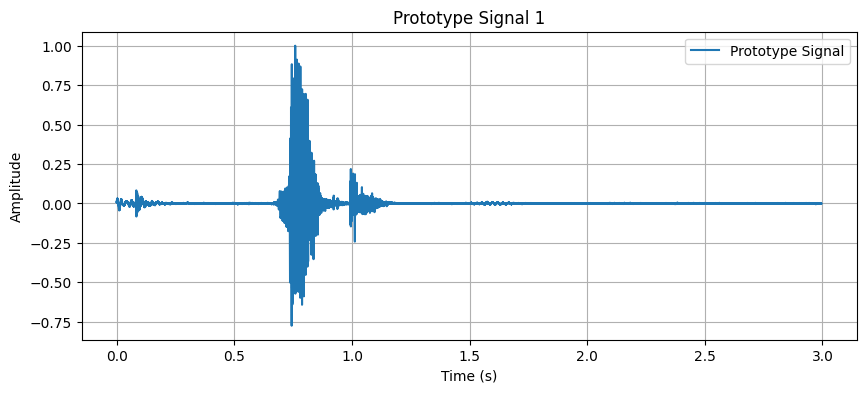

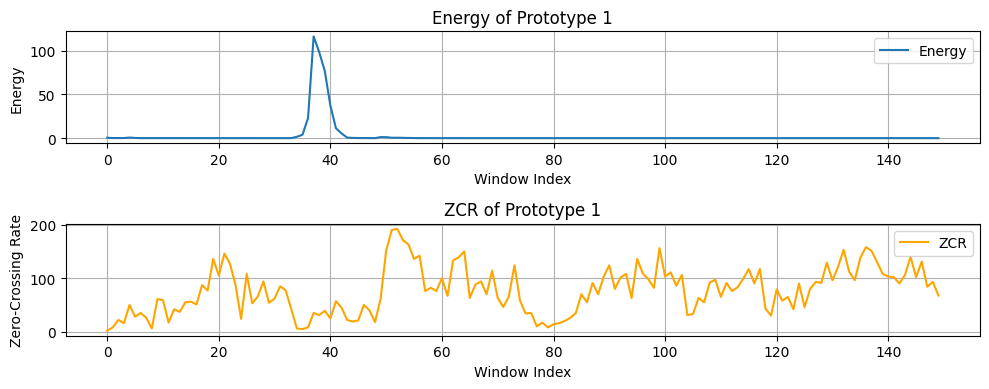

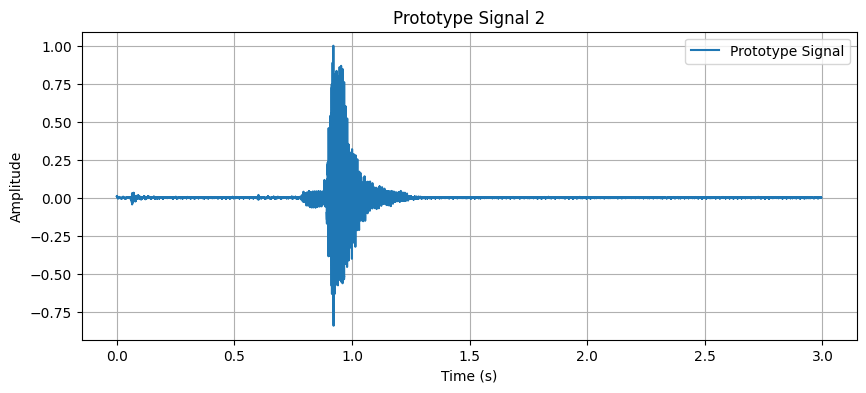

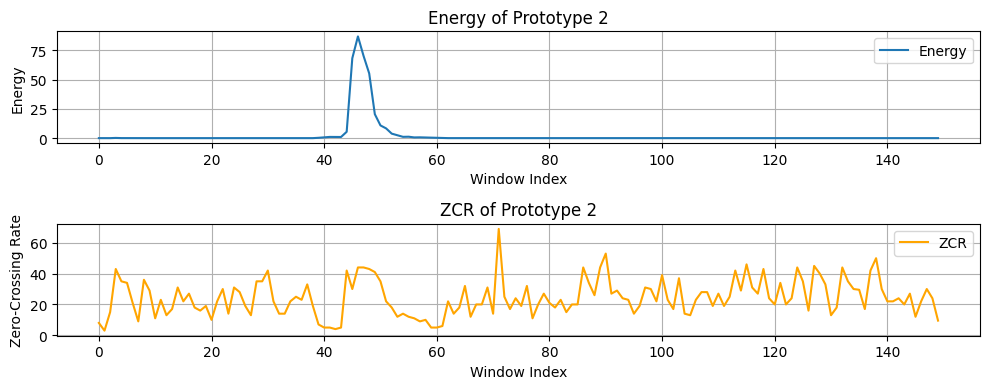

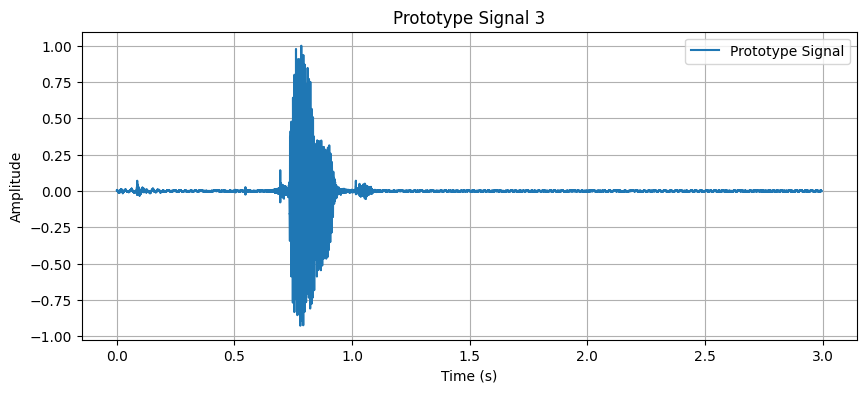

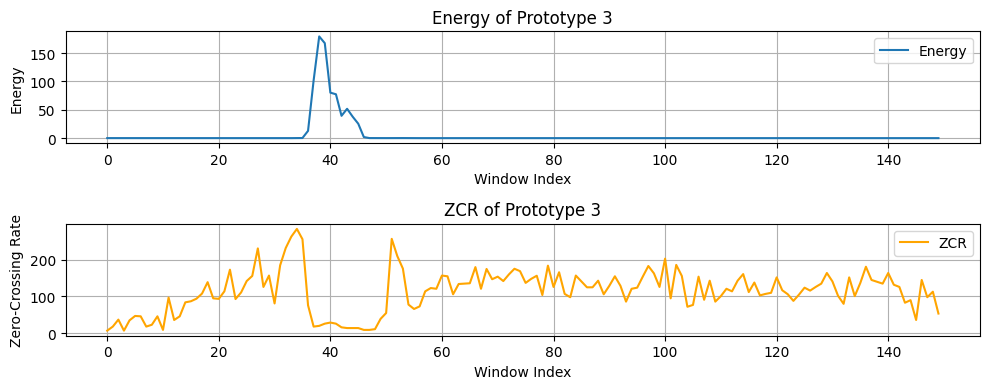

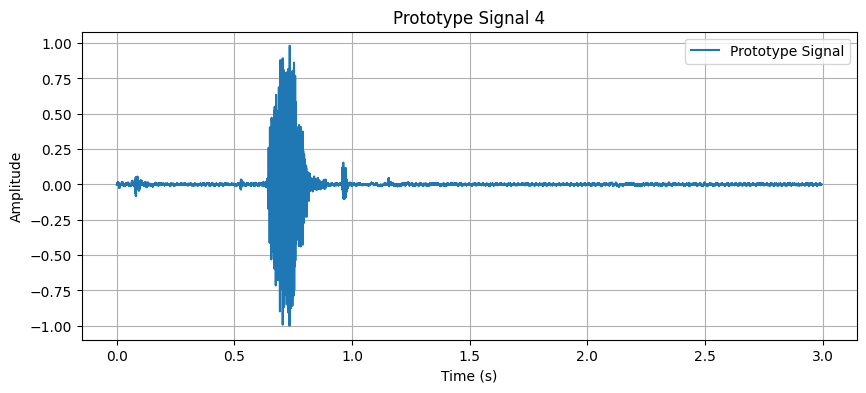

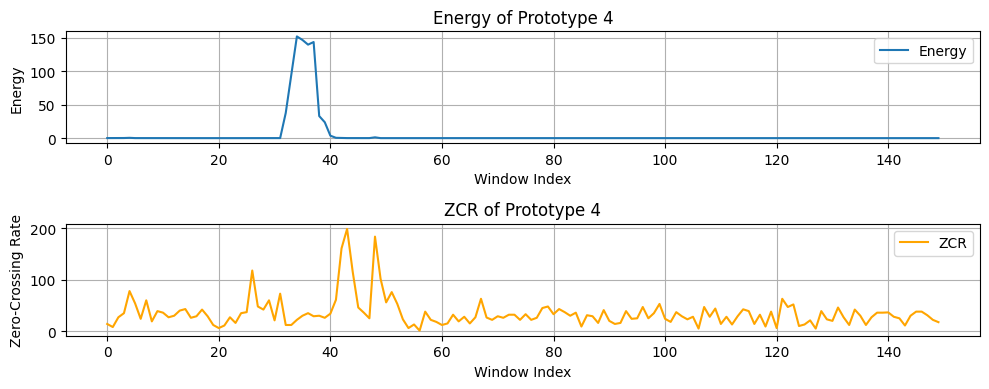

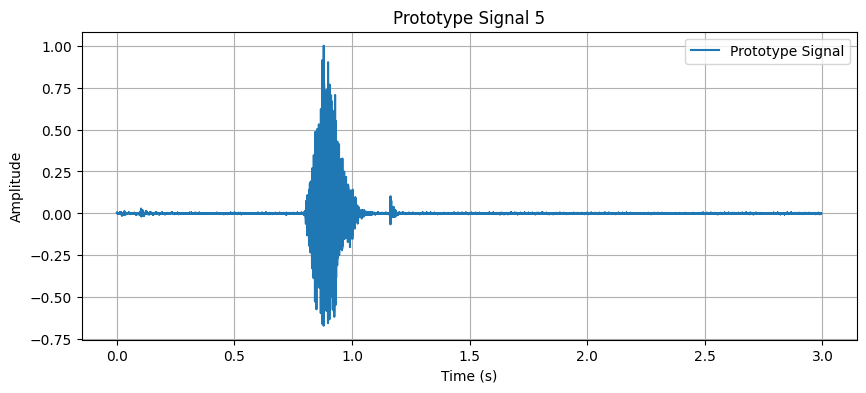

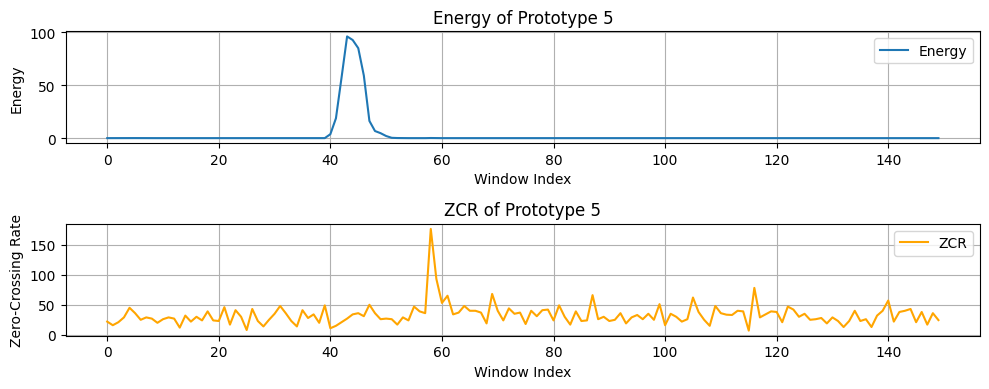

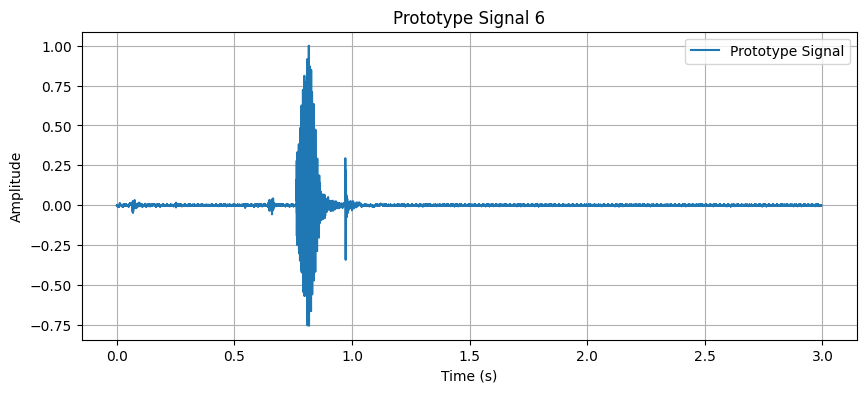

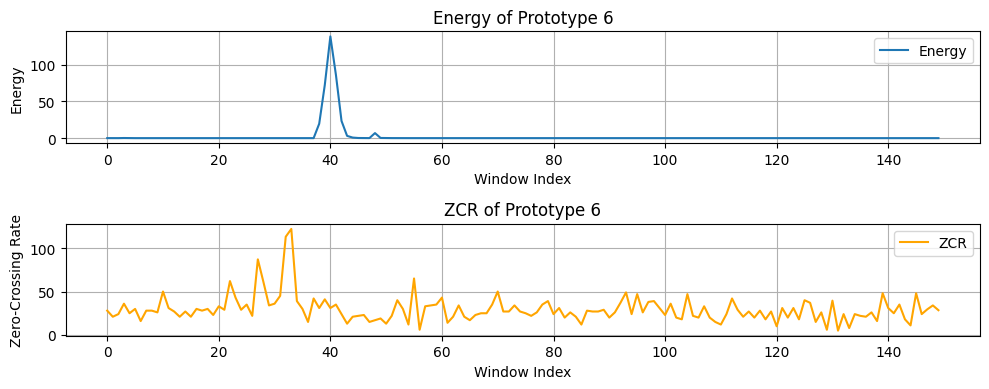

Available test files:
1: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\back1.wav
2: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\down1.wav
3: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\front1.wav
4: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\left1.wav
5: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\right1.wav
6: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\up1.wav
7: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test\voz.wav


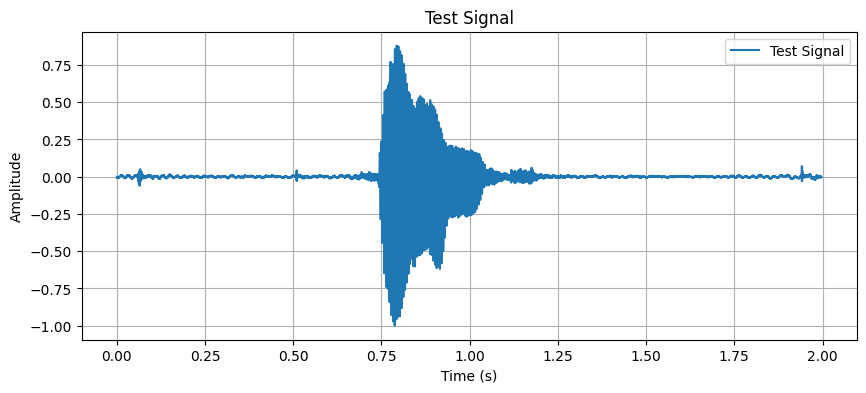

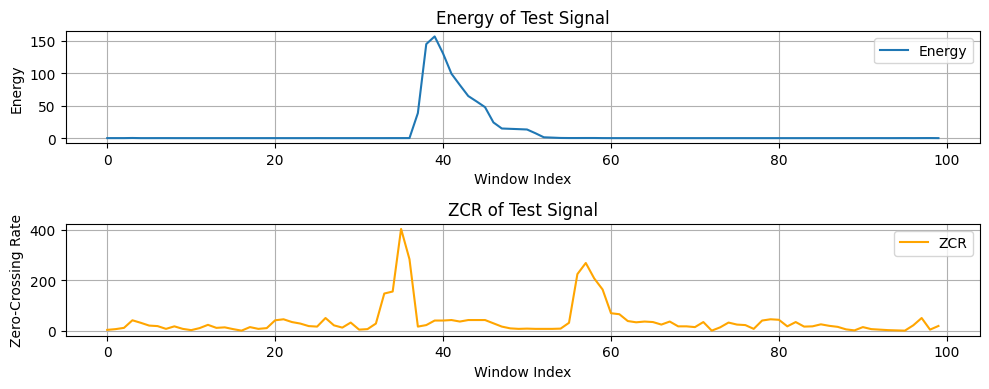

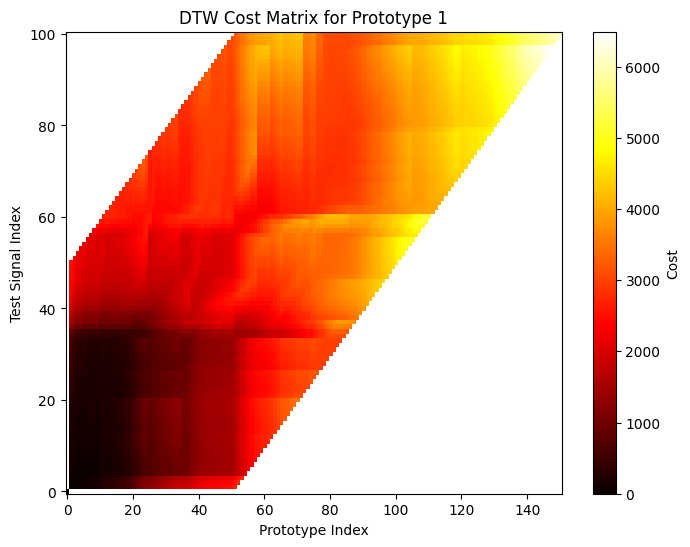

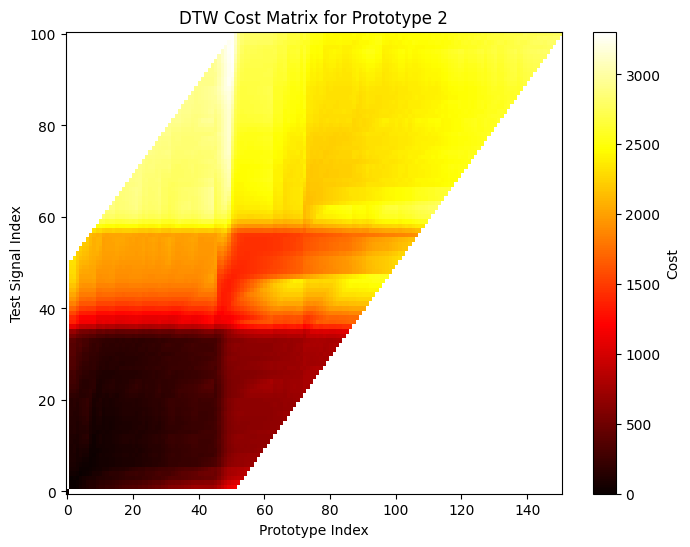

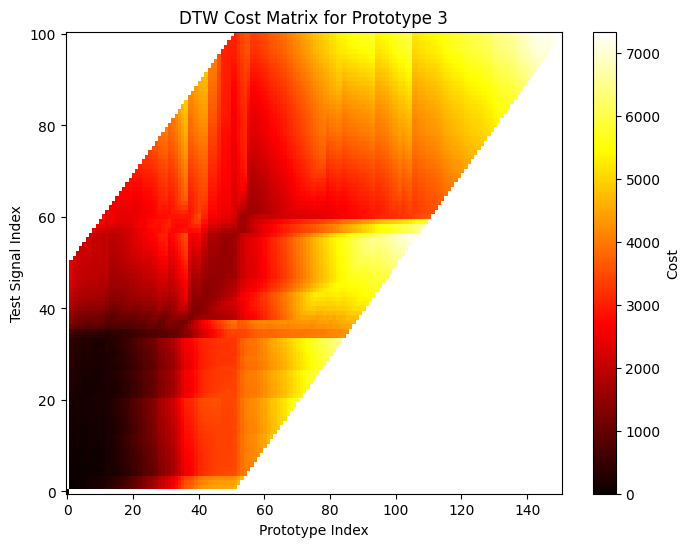

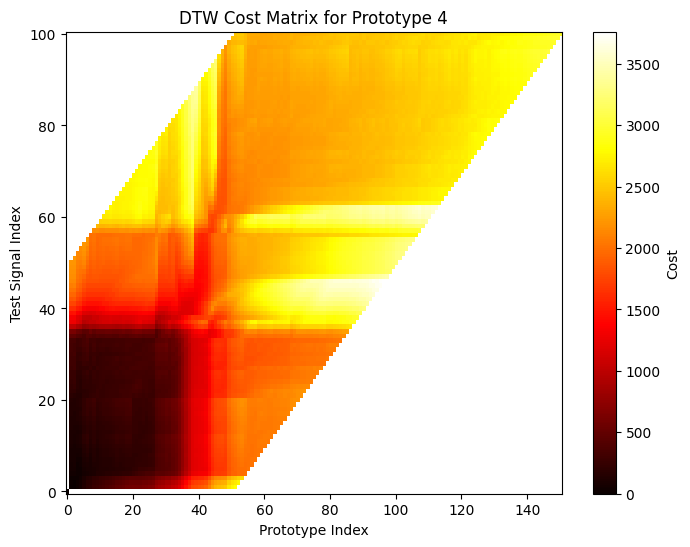

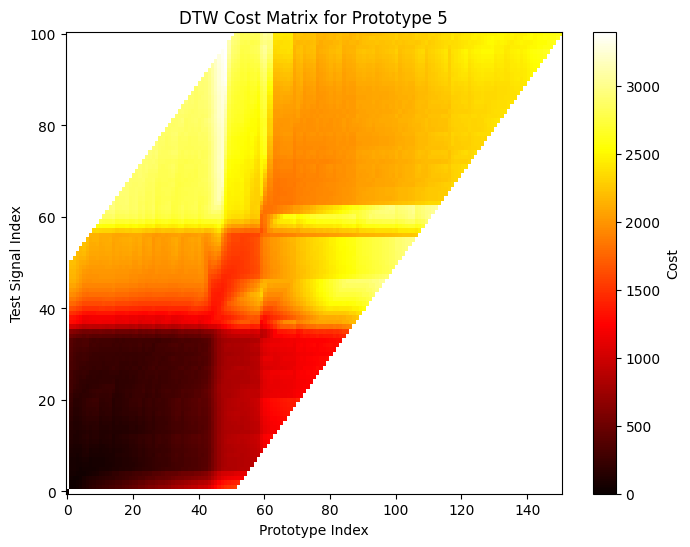

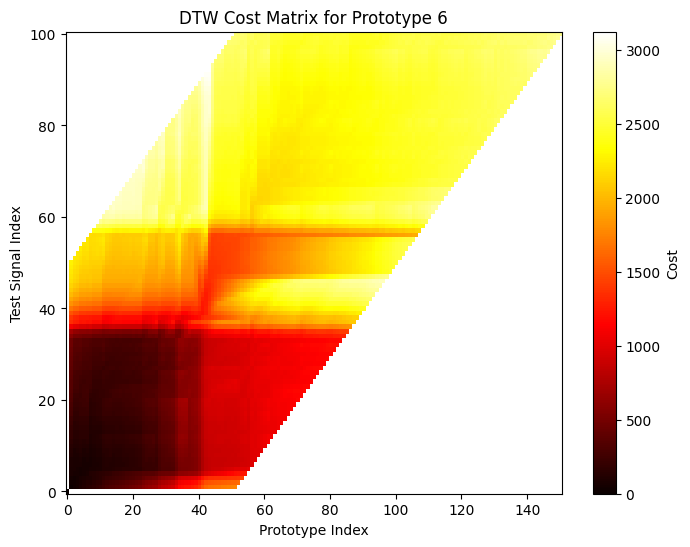

The unknown pattern has been identified as: D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train\right


In [13]:
#DTW por czr y energía

import wave
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import os

plt.close('all')

# # Load the WAV file
# file_path =r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\up.wav"

# with wave.open(file_path, 'rb') as wav_file:
#     params = wav_file.getparams()
#     n_channels, samp_width, frame_rate, n_frames, comp_type, comp_name = params[:6]
#     frames = wav_file.readframes(n_frames)
 
# # Convert byte data to numpy array
# data = np.frombuffer(frames, dtype=np.int16)
# duration = n_frames / frame_rate
 
# # Normalize the signal and compute its envelope
# data_norm = data / np.max(np.abs(data))
# threshold = 0.075  # Amplitude threshold
 
# # Find active regions
# active_idx = np.where(np.abs(data_norm) > threshold)[0]
# start_idx = active_idx[0]
# end_idx = active_idx[-1]
 
# # Trim the signal
# data_trimmed = data[start_idx:end_idx+1]
 
# # Plot original and trimmed signals
# time = np.linspace(0, duration, len(data))
# time_trimmed = np.linspace(start_idx / frame_rate, end_idx / frame_rate, len(data_trimmed))
 
# plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
# plt.plot(time, data, label="Original Signal")
# plt.title("Original Signal")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
 
# plt.subplot(2, 1, 2)
# plt.plot(time_trimmed, data_trimmed, label="Trimmed Signal", color='orange')
# plt.title("Trimmed Signal")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
 
# plt.tight_layout()
# # plt.show()
 
# Prototype audio file paths
# Define the directory containing audio files
audio_dir = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\train"

# Automatically list all WAV files in the directory
proto_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir) if f.endswith('.wav')]


# Store prototype features
proto_feats = []
 
# Window parameters
win_dur = 0.02  # 20 ms
 
# Process prototypes
for idx, file in enumerate(proto_files):
    # Read audio
    Fs, sig = wav.read(file)
    # Normalize
    sig = sig / np.max(np.abs(sig))
    # Convert to mono if stereo
    if len(sig.shape) > 1:
        sig = sig[:, 0]
    # Window length and step
    win_len = int(win_dur * Fs)
    step = win_len
    # Number of windows
    n_windows = int(np.ceil((len(sig) - win_len) / step)) + 1
    # Pad signal
    pad_len = n_windows * step + win_len
    sig_pad = np.append(sig, np.zeros(pad_len - len(sig)))
    # Energy and ZCR
    eng = []
    zcr = []
    for i in range(n_windows):
        start = i * step
        end = start + win_len
        win = sig_pad[start:end]
        eng.append(np.sum(win ** 2))
        zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)
    # Store features
    feats = np.column_stack((eng, zcr))
    proto_feats.append(feats)
 
    # Visualize prototype signal
    time = np.linspace(0, len(sig) / Fs, len(sig))
    plt.figure(figsize=(10, 4))
    plt.plot(time, sig, label="Prototype Signal")
    plt.title(f"Prototype Signal {idx+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()
 
    # Visualize energy and ZCR
    plt.figure(figsize=(10, 4))
    plt.subplot(2, 1, 1)
    plt.plot(eng, label="Energy")
    plt.title(f"Energy of Prototype {idx+1}")
    plt.xlabel("Window Index")
    plt.ylabel("Energy")
    plt.grid()
    plt.legend()
 
    plt.subplot(2, 1, 2)
    plt.plot(zcr, label="ZCR", color="orange")
    plt.title(f"ZCR of Prototype {idx+1}")
    plt.xlabel("Window Index")
    plt.ylabel("Zero-Crossing Rate")
    plt.grid()
    plt.legend()
 
    plt.tight_layout()
    plt.show()

    
# Test pattern
# Define the directory containing audio files for testing
test_dir = r"D:\Upiita\6to\Patrones\Proyectos\Carrito\audios\test"

# Automatically list all WAV files in the directory
test_files = [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith('.wav')]

# Display available files and prompt user to select one
print("Available test files:")
for i, file in enumerate(test_files):
    print(f"{i + 1}: {file}")

# Ask user for selection
selection = int(input("Select a file number to use for testing: ")) - 1

# Ensure valid selection
if 0 <= selection < len(test_files):
    test_file = test_files[selection]
else:
    raise ValueError("Invalid selection. Please restart and choose a valid file number.")


Fs, test_sig = wav.read(test_file)
test_sig = test_sig / np.max(np.abs(test_sig))
if len(test_sig.shape) > 1:
    test_sig = test_sig[:, 0]
# Window length and step
win_len = int(win_dur * Fs)
step = win_len
# Number of windows
n_windows = int(np.ceil((len(test_sig) - win_len) / step)) + 1
# Pad signal
pad_len = n_windows * step + win_len
test_sig_pad = np.append(test_sig, np.zeros(pad_len - len(test_sig)))
# Energy and ZCR
test_eng = []
test_zcr = []
for i in range(n_windows):
    start = i * step
    end = start + win_len
    win = test_sig_pad[start:end]
    test_eng.append(np.sum(win ** 2))
    test_zcr.append(np.sum(np.abs(np.diff(np.sign(win)))) / 2)
# Store test features
test_feats = np.column_stack((test_eng, test_zcr))
 
# Visualize test signal
time = np.linspace(0, len(test_sig) / Fs, len(test_sig))
plt.figure(figsize=(10, 4))
plt.plot(time, test_sig, label="Test Signal")
plt.title("Test Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()
 
# Visualize energy and ZCR of test signal
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(test_eng, label="Energy")
plt.title("Energy of Test Signal")
plt.xlabel("Window Index")
plt.ylabel("Energy")
plt.grid()
plt.legend()
 
plt.subplot(2, 1, 2)
plt.plot(test_zcr, label="ZCR", color="orange")
plt.title("ZCR of Test Signal")
plt.xlabel("Window Index")
plt.ylabel("Zero-Crossing Rate")
plt.grid()
plt.legend()
 
plt.tight_layout()
plt.show()

# DTW Recognition
tol_sec = 0.1  # Tolerance in seconds
tol_win = int(tol_sec / win_dur)
costs = []
 
for idx, proto in enumerate(proto_feats):
    n, m = len(proto), len(test_feats)
    win = max(tol_win, abs(n - m))
    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0
    for j in range(1, n + 1):
        for k in range(max(1, j - win), min(m + 1, j + win)):
            cost = np.linalg.norm(proto[j - 1] - test_feats[k - 1])
            dtw[j, k] = cost + min(dtw[j - 1, k], dtw[j, k - 1], dtw[j - 1, k - 1])
    costs.append(dtw[n, m])
 
    # Visualize DTW cost matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(dtw.T, origin="lower", cmap="hot", interpolation="nearest", aspect="auto")
    plt.title(f"DTW Cost Matrix for Prototype {idx+1}")
    plt.xlabel("Prototype Index")
    plt.ylabel("Test Signal Index")
    plt.colorbar(label="Cost")
    plt.show()
 
rec_idx = np.argmin(costs)
rec_pattern = proto_files[rec_idx].replace(".wav", "")
 
print(f"The unknown pattern has been identified as: {rec_pattern}")

#"Gráfico de distancias", entre más oscuro menor diferencia por lo que hay menos distancia entre el test y la muestra, entre más claro, menor similitud tendrá el test con la muestra"

In [3]:
# FFT

#Grabar audio
from scipy.io import wavfile 
import matplotlib.pyplot as plt
from winsound import *

import pyaudio
import wave
import numpy as np

#Parametros
formato=pyaudio.paInt16
canales=1
tasa_muestreo=44100
tamano_bloque=1024
tiempo_grabacion=3
nombre_archivo='p1.wav'

audio=pyaudio.PyAudio()

# Listar dispositivos de entrada
print("Dispositivos disponibles:")
for i in range(audio.get_device_count()):
    info = audio.get_device_info_by_index(i)
    print(f"ID: {i}, Nombre: {info['name']}")

# Seleccionar el dispositivo de entrada
index_selected = int(input("Introduce el ID del micrófono a utilizar: "))

try:
    flujo_sonido=audio.open(format=formato,channels=canales,rate=tasa_muestreo,
                            input=True,frames_per_buffer=tamano_bloque,input_device_index=index_selected)
    print('Inicia la grabación')
    datos_audio=[]
    fragmentos=[]
    for i in range(0,int(tasa_muestreo/tamano_bloque*tiempo_grabacion)):
        datos_bloque=flujo_sonido.read(tamano_bloque)
        datos_audio.append(datos_bloque)
        fragmentos.append(np.frombuffer(datos_bloque,dtype = np.int16))
    senal_audio = np.hstack(fragmentos)
    if np.max(np.abs(senal_audio))!=0:
        senal_audio=senal_audio/np.max(np.abs(senal_audio))*32767 #El 32767 proviene de la magnitud debida al tipo de dato "int16" 2^16 y se trabaja con 16 bits para una mejor resolución (Se le sube el volumen)
        senal_audio=senal_audio.astype(np.int16)

    print('Termina la Grabación')
    flujo_sonido.stop_stream()
    flujo_sonido.close()

finally:
    audio.terminate()
    
# ruta_señal = r"D:\Upiita\6to\Patrones\Objetos\voz.wav"

# # Cargar la señal de sonido
# fs, señal = wavfile.read(ruta_señal)
# archivo_wave=wave.open(nombre_archivo,'wb')
archivo_wave=wave.open(nombre_archivo,'wb')
archivo_wave.setnchannels(canales)
archivo_wave.setsampwidth(audio.get_sample_size(formato))
archivo_wave.setframerate(tasa_muestreo)
archivo_wave.writeframes(b''.join([senal_audio.tobytes()]))
archivo_wave.close()

PlaySound(nombre_archivo,SND_FILENAME|SND_ASYNC)

senal_normal=senal_audio/np.max(np.abs(senal_audio))  #normalizada
Bin1=np.where(np.abs(senal_normal)>=0.1,1,0)
ventana=440 #Tamaño de la ventana es de 10 mseg 
senal1=np.convolve(Bin1,np.ones(ventana)/ventana,mode='same')
Bin2=np.where(np.abs(senal1)>=0.1,1,0)
senal_activa=senal_normal[Bin2==1]

plt.figure(1)
plt.plot(senal_activa)

#Filtro de Pre énfasis
alpha=0.95 #Factor de pre énfasis
pre=np.roll(senal_activa,1)-alpha*senal_activa
pre[0]=0 #Primer valor en cero tras el desplazamiento
pre=np.where(np.abs(pre)>=0.7,0,pre) #Elimina cierta varianza aguda que se puede presentar por el tipo de micrófono a utilizar
plt.figure(2)
plt.plot(pre)
plt.title('Forma de Onda de la Grabación')

frame=441
overlap=397
ventanas=range(0,len(pre)-frame+1,overlap)
espectro=[]

for i in ventanas:
    segmento=pre[i:i+frame]*np.hamming(frame)
    Fourier=np.abs(np.fft.fft(segmento))[:150]
    espectro.append(Fourier)

Z=np.array(espectro).T #Transpuesta para cada columna sea el tiempo
plt.figure(3)
plt.imshow(Z,aspect='auto',origin='lower',cmap='viridis',extent=[0,len(ventanas),0,150])
plt.colorbar(label='Amplitud')
plt.title('Espectrograma de Fourier')

#Vista en 3 dimensiones
X,Y=np.meshgrid(np.arange(Z.shape[1]),np.arange(Z.shape[0]))
fig=plt.figure(4)
ax=fig.add_subplot(111,projection='3d')
surf=ax.plot_surface(X,Y,Z,cmap='viridis',edgecolor='none')
ax.set_xlabel('tiempo')

#Generar el patrón de las palabras

comp1=np.max(np.array(espectro),axis=0)
comp2=np.mean(np.array(espectro),axis=0)
patron=(comp1+comp2)/2
plt.figure(5)
plt.plot(patron)
plt.title('vector Patron')

muestra=1
#Grabar base de datos
# nombre_archivo=f"Jugo_0{muestra}.npy"#f"Cafe_0{muestra}.npy"#f"Agua_0{muestra}.npy"
# np.save(nombre_archivo,patron)
#Cargar base de datos
# palabra1=f"Agua_0{muestra}.npy"
# palabra2=f"Cafe_0{muestra}.npy"
# palabra3=f"Jugo_0{muestra}.npy"
# p1=np.load(palabra1)
# p2=np.load(palabra2)
# p3=np.load(palabra3)

# print(np.corrcoef(patron,p1))
# print(np.corrcoef(patron,p2))
# print(np.corrcoef(patron,p3))

#Clasificador if argmax, entrenar arquitectura neuronal
# plt.show()

Dispositivos disponibles:
ID: 0, Nombre: Microsoft Sound Mapper - Input
ID: 1, Nombre: Microphone (HyperX Quadcast)
ID: 2, Nombre: Microphone (Iriun Webcam)
ID: 3, Nombre: MicrÃ³fono (Steam Streaming Micr
ID: 4, Nombre: MicrÃ³fono (Realtek(R) Audio)
ID: 5, Nombre: Microsoft Sound Mapper - Output
ID: 6, Nombre: Altavoces (HyperX Quadcast)
ID: 7, Nombre: 1 - T22B350 (AMD High Definitio
ID: 8, Nombre: Altavoces (Steam Streaming Micr
ID: 9, Nombre: Altavoces (Steam Streaming Spea
ID: 10, Nombre: Altavoces (Realtek(R) Audio)
ID: 11, Nombre: Primary Sound Capture Driver
ID: 12, Nombre: Microphone (HyperX Quadcast)
ID: 13, Nombre: Microphone (Iriun Webcam)
ID: 14, Nombre: MicrÃ³fono (Steam Streaming Microphone)
ID: 15, Nombre: MicrÃ³fono (Realtek(R) Audio)
ID: 16, Nombre: Primary Sound Driver
ID: 17, Nombre: Altavoces (HyperX Quadcast)
ID: 18, Nombre: 1 - T22B350 (AMD High Definition Audio Device)
ID: 19, Nombre: Altavoces (Steam Streaming Microphone)
ID: 20, Nombre: Altavoces (Steam Streamin

ValueError: invalid literal for int() with base 10: 'c'

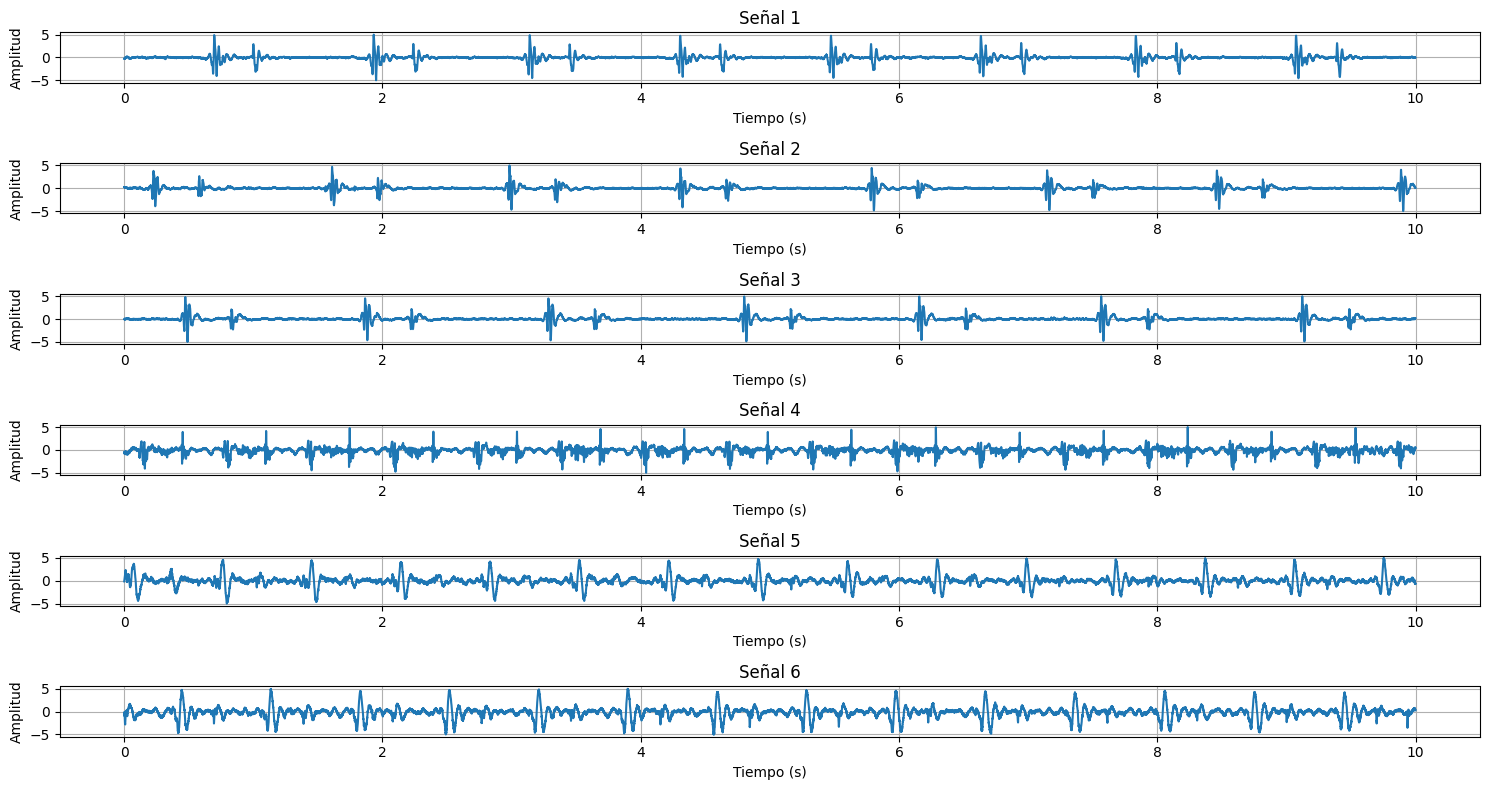

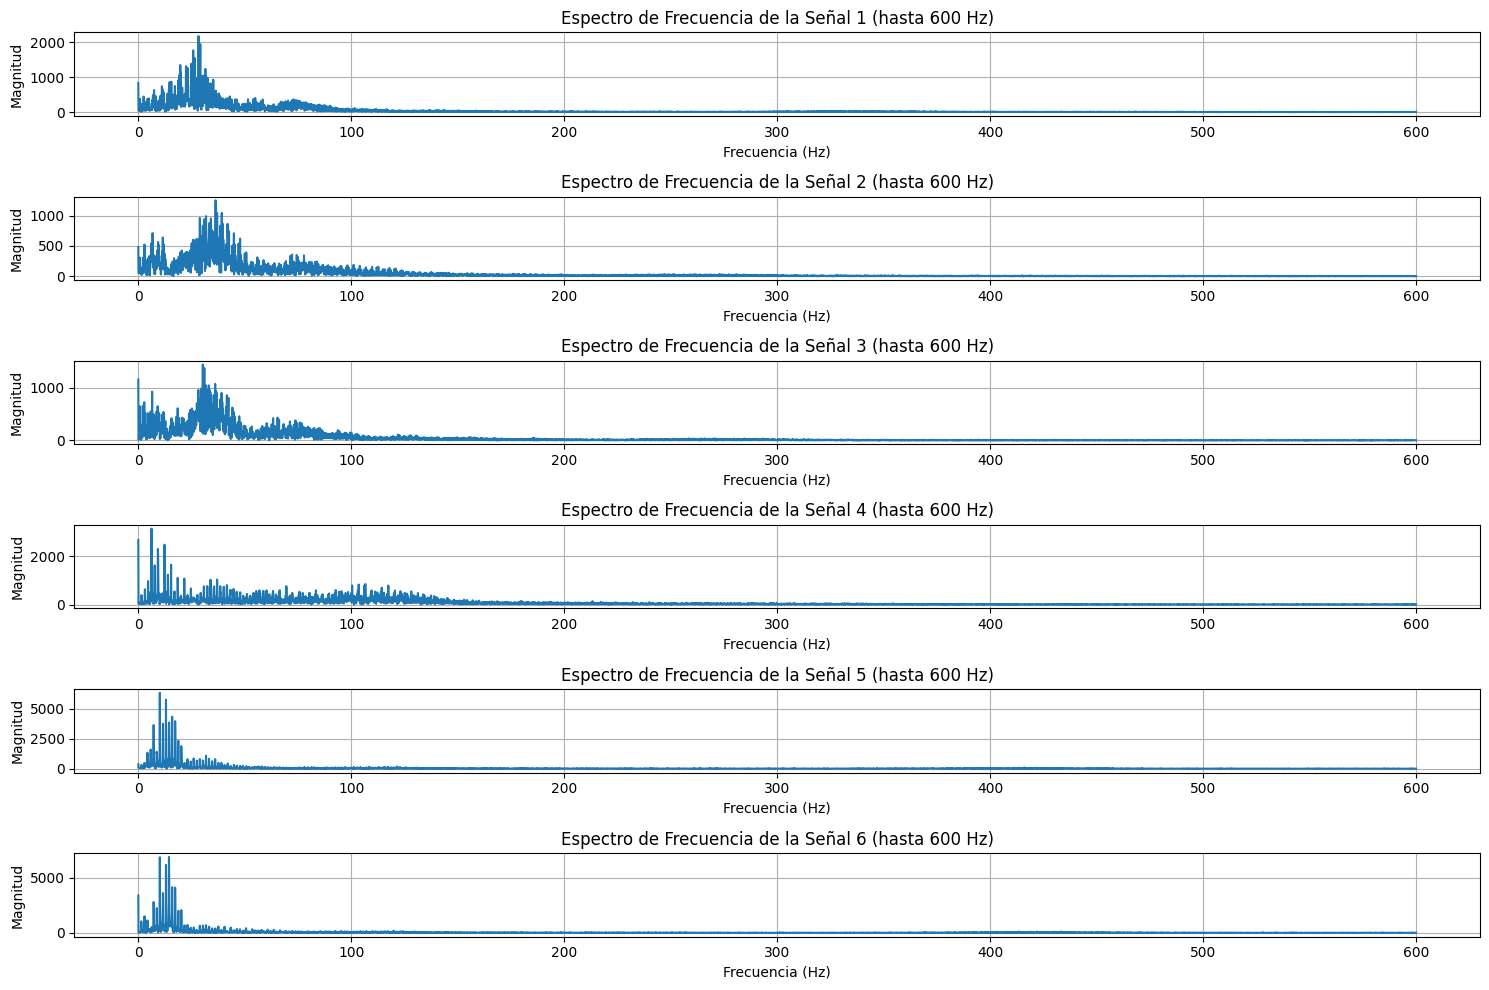

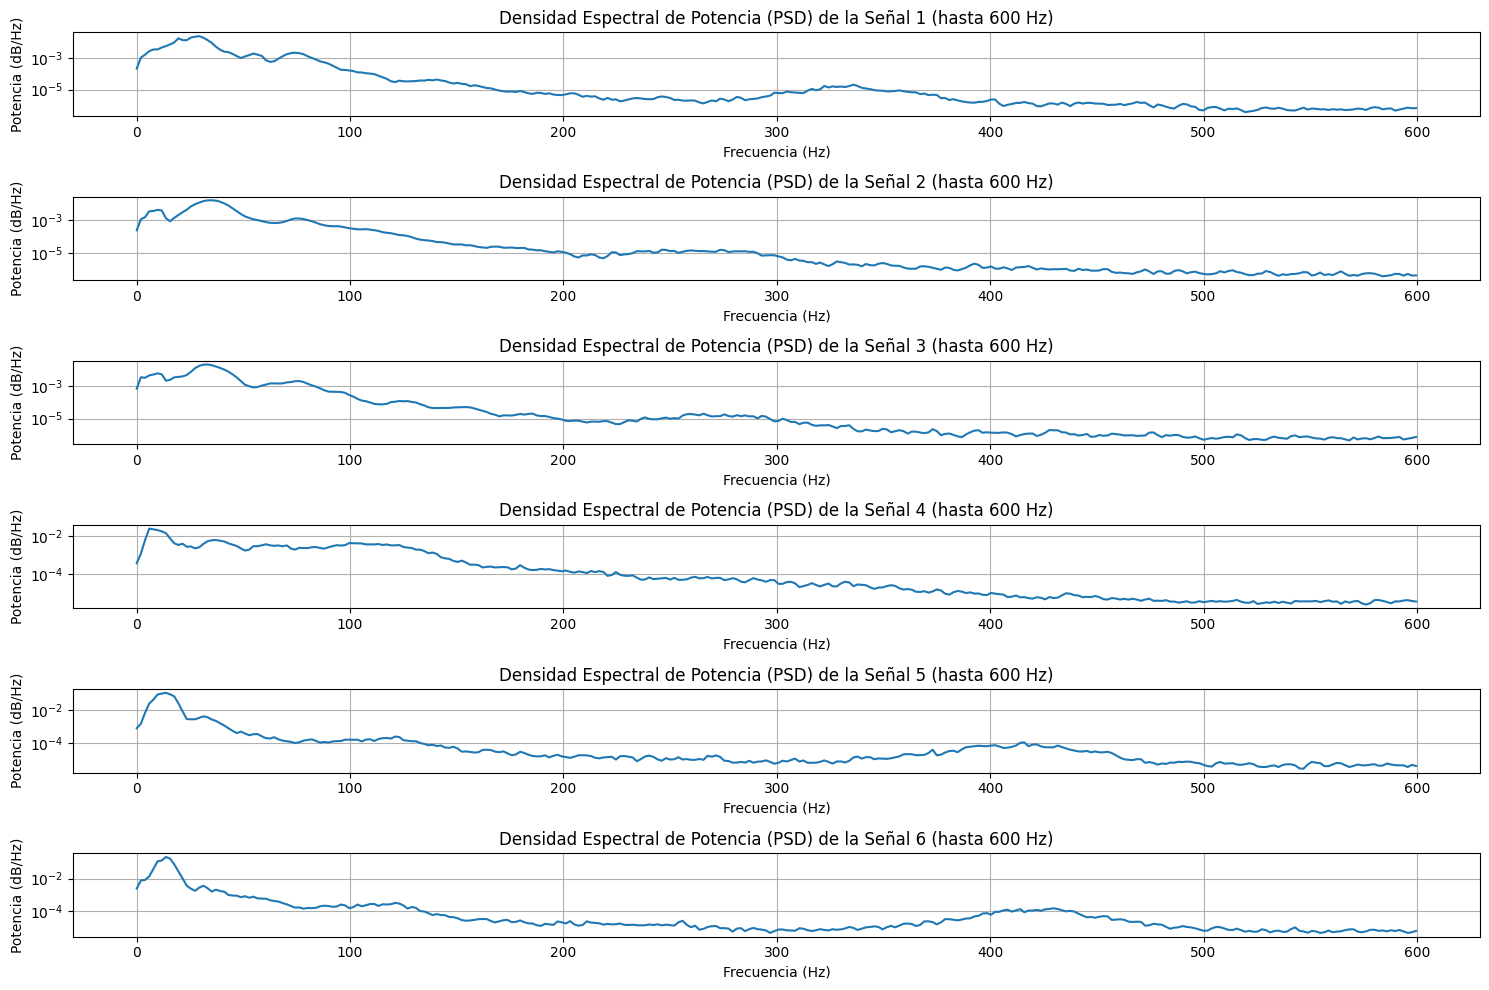

Distancia Euclidiana en el dominio de la frecuencia:
Matriz de distancias (frecuencia):
[[    0.          7720.73692809  8032.28450315 11616.18835367
  15730.15048957 17778.74250943]
 [ 7720.73692809     0.          5362.94723832 10253.68175954
  15350.05441143 17858.14323706]
 [ 8032.28450315  5362.94723832     0.         10455.60206741
  15630.6732364  17916.28575884]
 [11616.18835367 10253.68175954 10455.60206741     0.
  17430.59050074 18982.84167694]
 [15730.15048957 15350.05441143 15630.6732364  17430.59050074
      0.          7556.3166663 ]
 [17778.74250943 17858.14323706 17916.28575884 18982.84167694
   7556.3166663      0.        ]]

Correlación cruzada en el dominio del tiempo:
Matriz de correlaciones:
[[    0.          2149.92036935  2232.8660327   1440.79562628
   1109.75374265  1306.71800531]
 [ 2149.92036935     0.          5264.14197161  1159.77808303
   1092.68245717   829.9922845 ]
 [ 2232.8660327   5264.14197161     0.          1014.90890808
   1090.52106049   631.29

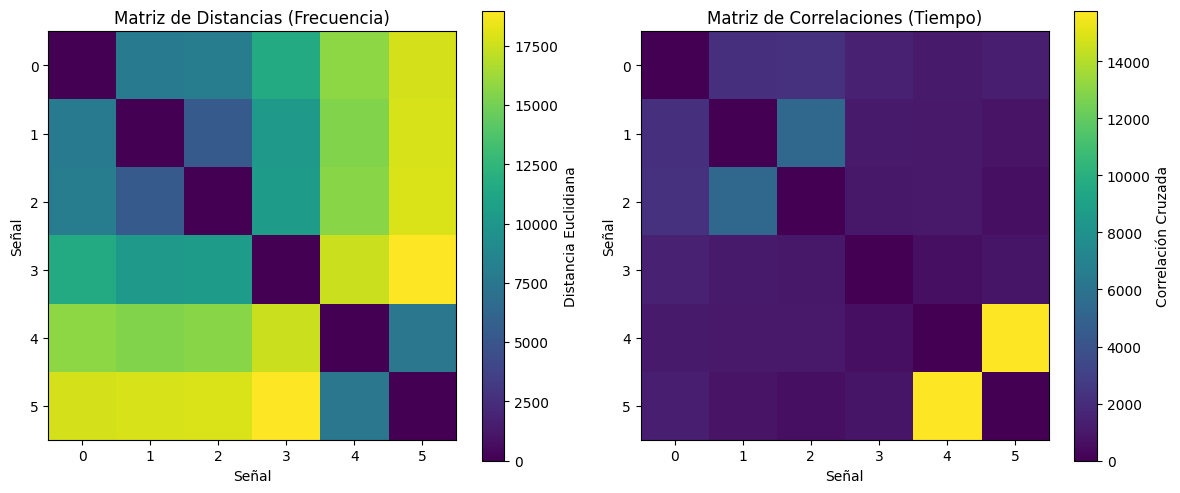

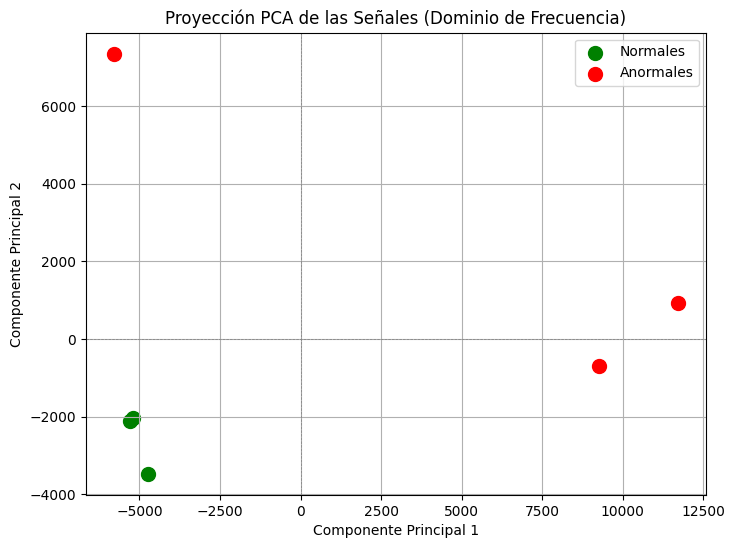

In [14]:
#PCA

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, welch
from scipy.spatial.distance import euclidean
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
 
plt.close("all")
 
# Cargar los datos desde el archivo
file_path = r"D:\Upiita\6to\Patrones\Objetos\Signals10seg.txt"

data = np.loadtxt(file_path)
 
# Parámetros
fs = 2000  # Frecuencia de muestreo
t = np.arange(data.shape[0]) / fs  # Vector de tiempo basado en la frecuencia de muestreo
 
# Visualizar las señales
plt.figure(figsize=(15, 8))
for i in range(data.shape[1]):
    plt.subplot(6, 1, i + 1)
    plt.plot(t, data[:, i])
    plt.title(f'Señal {i + 1}')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.grid()
 
plt.tight_layout()
plt.show()
 
# Análisis en el dominio de la frecuencia
plt.figure(figsize=(15, 10))
frequencies = np.fft.rfftfreq(data.shape[0], d=1/fs)  # Frecuencias correspondientes
max_frequency = 600  # Frecuencia máxima a mostrar
for i in range(data.shape[1]):
    fft_magnitude = np.abs(np.fft.rfft(data[:, i]))  # Magnitud de la FFT
 
    # Filtrar hasta 600 Hz
    freq_mask = frequencies <= max_frequency
    filtered_frequencies = frequencies[freq_mask]
    filtered_magnitude = fft_magnitude[freq_mask]
 
    # Graficar
    plt.subplot(6, 1, i + 1)
    plt.plot(filtered_frequencies, filtered_magnitude)
    plt.title(f'Espectro de Frecuencia de la Señal {i + 1} (hasta 600 Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Magnitud')
    plt.grid()
 
plt.tight_layout()
plt.show()

# Análisis de Densidad Espectral de Potencia (PSD)
plt.figure(figsize=(15, 10))
for i in range(data.shape[1]):
    # Calcular la PSD usando el método de Welch
    psd_frequencies, psd = welch(data[:, i], fs=fs, nperseg=1024)
 
    # Filtrar hasta 600 Hz
    psd_mask = psd_frequencies <= max_frequency
    filtered_psd_frequencies = psd_frequencies[psd_mask]
    filtered_psd = psd[psd_mask]
 
    # Graficar la PSD
    plt.subplot(6, 1, i + 1)
    plt.semilogy(filtered_psd_frequencies, filtered_psd)  # Escala logarítmica para PSD
    plt.title(f'Densidad Espectral de Potencia (PSD) de la Señal {i + 1} (hasta 600 Hz)')
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Potencia (dB/Hz)')
    plt.grid()
 
plt.tight_layout()
plt.show()
 
# --------------------
# 1. Distancia Euclidiana en el dominio de la frecuencia
# --------------------
print("Distancia Euclidiana en el dominio de la frecuencia:")
frequencies = np.fft.rfftfreq(data.shape[0], d=1/fs)  # Frecuencias correspondientes
distances = np.zeros((data.shape[1], data.shape[1]))
 
for i in range(data.shape[1]):
    for j in range(data.shape[1]):
        if i != j:
            # Calcula FFT
            fft_i = np.abs(np.fft.rfft(data[:, i]))
            fft_j = np.abs(np.fft.rfft(data[:, j]))
 
            # Filtra hasta 600 Hz
            freq_mask = frequencies <= max_frequency
            fft_i_filtered = fft_i[freq_mask]
            fft_j_filtered = fft_j[freq_mask]
 
            # Calcula la distancia Euclidiana
            distances[i, j] = euclidean(fft_i_filtered, fft_j_filtered)
 
# Mostrar matriz de distancias
print("Matriz de distancias (frecuencia):")
print(distances)
 
# --------------------
# 2. Correlación cruzada en el dominio del tiempo
# --------------------
print("\nCorrelación cruzada en el dominio del tiempo:")
correlations = np.zeros((data.shape[1], data.shape[1]))
 
for i in range(data.shape[1]):
    for j in range(data.shape[1]):
        if i != j:
            # Calcula la correlación cruzada normalizada
            corr = correlate(data[:, i], data[:, j], mode='full')
            correlations[i, j] = np.max(corr) / (np.std(data[:, i]) * np.std(data[:, j]))
 
# Mostrar matriz de correlaciones
print("Matriz de correlaciones:")
print(correlations)
 
# --------------------
# Visualizar las matrices
# --------------------
plt.figure(figsize=(12, 5))
 
# Distancia Euclidiana
plt.subplot(1, 2, 1)
plt.imshow(distances, cmap='viridis', interpolation='none')
plt.colorbar(label='Distancia Euclidiana')
plt.title('Matriz de Distancias (Frecuencia)')
plt.xlabel('Señal')
plt.ylabel('Señal')
 
# Correlación cruzada
plt.subplot(1, 2, 2)
plt.imshow(correlations, cmap='viridis', interpolation='none')
plt.colorbar(label='Correlación Cruzada')
plt.title('Matriz de Correlaciones (Tiempo)')
plt.xlabel('Señal')
plt.ylabel('Señal')
 
plt.tight_layout()
plt.show()

# Preparar los datos en el dominio de la frecuencia (FFT) para PCA compresión de datos
fft_data = []
for i in range(data.shape[1]):
    fft_magnitude = np.abs(np.fft.rfft(data[:, i]))  # Magnitud de la FFT
    freq_mask = frequencies <= max_frequency        # Filtrar hasta 600 Hz
    fft_data.append(fft_magnitude[freq_mask])
 
fft_data = np.array(fft_data)  # Convertir a matriz
 
# Aplicar PCA al dominio de frecuencia
pca = PCA(n_components=2)  # Reducimos a 2 componentes principales
fft_pca_result = pca.fit_transform(fft_data)
 
# Visualizar los resultados de PCA
plt.figure(figsize=(8, 6))
plt.scatter(fft_pca_result[:3, 0], fft_pca_result[:3, 1], color='green', label='Normales', s=100)
plt.scatter(fft_pca_result[3:, 0], fft_pca_result[3:, 1], color='red', label='Anormales', s=100)
plt.title('Proyección PCA de las Señales (Dominio de Frecuencia)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid()
plt.show()

In [ ]:
#DTW señal

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def optimized_dtw_distance(signal1, signal2):
    """
    Calcula la distancia DTW entre dos señales de forma optimizada usando solo dos filas de la matriz.
    :param signal1: Primera señal (array)
    :param signal2: Segunda señal (array)
    :return: Distancia DTW
    """
    n, m = len(signal1), len(signal2)
    prev_row = np.full(m + 1, np.inf)
    curr_row = np.full(m + 1, np.inf)
    prev_row[0] = 0
 
    for i in range(1, n + 1):
        curr_row[0] = np.inf
        for j in range(1, m + 1):
            cost = abs(signal1[i - 1] - signal2[j - 1])
            curr_row[j] = cost + min(prev_row[j], curr_row[j - 1], prev_row[j - 1])
        prev_row, curr_row = curr_row, prev_row
 
    return prev_row[m]



file_path = r"D:\Upiita\6to\Patrones\Objetos\Signals10seg.txt"
data = np.loadtxt(file_path)

fs = 2000  # Frecuencia de muestreo
duration = 2  # Duración en segundos
samples = fs * duration  # Número de muestras para 2 segundos
short_data = data[:samples, :]  # Tomar las primeras 2 segundos de cada señal
 
# Reducir la resolución temporal (muestreo reducido)
downsample_factor = 4  # Reducir la frecuencia de muestreo a 1/4 (500 Hz)
downsampled_data = short_data[::downsample_factor, :]  # Reducir las muestras

num_signals = downsampled_data.shape[1]
dtw_distances = np.zeros((num_signals, num_signals))
 
for i in range(num_signals):
    for j in range(num_signals):
        if i != j:
            # Calcular DTW entre la señal i y la señal j
            distance = optimized_dtw_distance(downsampled_data[:, i], downsampled_data[:, j])
            dtw_distances[i, j] = distance

plt.figure(figsize=(8, 6))
plt.imshow(dtw_distances, cmap='viridis', interpolation='none')
plt.colorbar(label='Distancia DTW')
plt.title('Matriz de Distancias DTW (2 segundos, muestreo reducido)')
plt.xlabel('Señal')
plt.ylabel('Señal')
plt.xticks(ticks=range(num_signals), labels=[f"S{i+1}" for i in range(num_signals)])
plt.yticks(ticks=range(num_signals), labels=[f"S{i+1}" for i in range(num_signals)])
plt.show()